# Global EDA

The objective of this analysis is to understand the overall characteristics of the Online Retail II business before moving into detailed customer and product analytics.

The plan for our Customer Analytics project is as shown below:

                    ONLINE RETAIL II
                          │
          ┌───────────────┼────────────────┐
          │               │                │
      BUSINESS        CUSTOMERS         PRODUCTS
     PERFORMANCE       │                │
          │            │                │
          │       Segmentation      Product analysis
          │       CLV               Basket analysis
          │       Retention         NLP categories
          │
          └───────────────┬────────────────┘
                          │
                   BUSINESS DECISIONS
                          │
          ┌───────────────┼────────────────┐
          │               │                │
      Marketing       Customer         Product/
      strategy        retention        inventory
                                      strategy
                          │
                       POWER BI

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [40]:
# df = pd.read_csv('data/cleaned_data.csv')

df = pd.read_parquet('data/cleaned_data.parquet', engine='pyarrow')
df['InvoiceMonth'] = df['InvoiceDateTime'].dt.to_period('M')

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1027838 entries, 0 to 1027837
Data columns (total 17 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   Invoice           1027838 non-null  str           
 1   StockCode         1027838 non-null  str           
 2   Description       1027838 non-null  str           
 3   Quantity          1027838 non-null  int64         
 4   InvoiceDate       1027838 non-null  object        
 5   Price             1027838 non-null  float64       
 6   CustomerID        1027838 non-null  str           
 7   Country           1027838 non-null  str           
 8   InvoiceDateTime   1027838 non-null  datetime64[us]
 9   InvoiceTime       1027838 non-null  object        
 10  InvoiceHour       1027838 non-null  int32         
 11  InvoiceDayOfWeek  1027838 non-null  str           
 12  is_guest          1027838 non-null  bool          
 13  is_cancellation   1027838 non-null  bool          
 1

## Overview

In [42]:
total_transaction_lines = len(df)
total_transactions = df['Invoice'].nunique()
total_identified_customers = df[~df['is_guest']]['CustomerID'].nunique()
total_guests = df[df['is_guest']]['CustomerID'].nunique()
total_customers = df['CustomerID'].nunique()
total_products = df[~df['is_non_product']]['StockCode'].nunique()
total_countries = df['Country'].nunique()
total_revenue = df['Revenue'].sum()
total_orders = df[~df['is_cancellation']]['Invoice'].nunique()
net_units_sold = df['Quantity'].sum()   # Include cancellations as well

In [43]:
print(f"Total number of invoices/transactions: {total_transactions}")
print(f"Total number of unique identified customers: {total_identified_customers}")
print(f"Total number of unique unidentified customers: {total_guests}")
print(f"Total number of unique customers: {total_customers}")
print(f"Total number of unique products: {total_products}")
print(f"Total number of unique countries: {total_countries}")
print(f"Total revenue: {total_revenue}")
print(f"Total number of orders: {total_orders}")
print(f"Net units sold: {net_units_sold}")

Total number of invoices/transactions: 49188
Total number of unique identified customers: 5878
Total number of unique unidentified customers: 4931
Total number of unique customers: 10809
Total number of unique products: 4910
Total number of unique countries: 43
Total revenue: 19349616.557
Total number of orders: 41489
Net units sold: 10970728


Note that here we are assuming that the guest IDs we created represent unique guests as we named them. We cannot be sure as the ids were missing.

In [44]:
guests = df[df['is_guest']]
print(f"Revenue share of guests: {guests['Revenue'].sum() / df['Revenue'].sum():.2%}")

Revenue share of guests: 14.83%


In [45]:
avg_guest_order = guests.groupby('Invoice')['Revenue'].sum().mean()
avg_identified_order = df[~df['is_guest']].groupby('Invoice')['Revenue'].sum().mean()
avg_order_size = df.groupby('Invoice')['Revenue'].sum().mean()
print(f"Guest average order value: £{avg_guest_order:.2f}")
print(f"Identified average order value: £{avg_identified_order:.2f}")
print(f"Overall average order value: £{avg_order_size:.2f}")

Guest average order value: £581.89
Identified average order value: £372.38
Overall average order value: £393.38


- Guest vs identified order value flip is interesting — guests order more per transaction (£581 vs £372) but contribute less revenue overall because there are fewer of them.

In [46]:
returns = df[df['is_cancellation'] & (~df['is_non_product'])]
total_unit_returns = abs(returns['Quantity'].sum())
total_return_invoices = returns['Invoice'].nunique()
total_revenue_return = abs(returns['Revenue'].sum())
gross_units_sold = df.loc[(df['Quantity'] > 0) & (~df['is_non_product']), 'Quantity'].sum()
return_rate = total_unit_returns / gross_units_sold
print(f"Total number of cancellations/returns: {total_unit_returns}")
print(f"Total number of cancellations/returns invoices: {total_return_invoices}")
print(f"Value of cancelled/returned items: £{total_revenue_return}")
print(f"Return Rate: {return_rate:.4f}")

Total number of cancellations/returns: 467740
Total number of cancellations/returns invoices: 7406
Value of cancelled/returned items: £716462.57
Return Rate: 0.0409


- The dataset contains approximately 1.03 million transaction lines across 49,188 invoices, generating £19.35M in net revenue across 43 countries and 4,910 products. 
- A total of 5,878 identifiable customers can be analysed at the customer level, while transactions associated with unidentified customers account for approximately 14.8% of net revenue. 
- Orders without an identifiable customer ID have a substantially higher average order value than identified-customer orders (£581 vs £372), suggesting differences in basket size or purchasing behaviour that warrant further investigation. 
- The retailer also exhibits a measurable level of cancellation/return activity, with approximately 471k units associated with cancellations and a return rate of 4.12%.

## Country 

In [47]:
df['Country'].value_counts(normalize=True)

Country
United Kingdom          0.917813
EIRE                    0.017116
Germany                 0.016841
France                  0.013631
Netherlands             0.004989
Spain                   0.003642
Switzerland             0.003089
Belgium                 0.003024
Portugal                0.002444
Australia               0.001832
Channel Islands         0.001598
Italy                   0.001463
Sweden                  0.001319
Norway                  0.001261
Cyprus                  0.001124
Finland                 0.001017
Austria                 0.000910
Denmark                 0.000775
Unspecified             0.000730
Greece                  0.000645
Japan                   0.000546
USA                     0.000520
Poland                  0.000513
United Arab Emirates    0.000484
Israel                  0.000358
Hong Kong               0.000341
Singapore               0.000323
Malta                   0.000287
Canada                  0.000222
Iceland                 0.000216
RS

- 91% of the data consists of transactions made in the UK. The rest 9% between all other countries.

In [48]:
print(f"Total Revenue generated by United Kingdom: {df[df['Country'] == 'United Kingdom']['Revenue'].sum()}")
print(f"Total Revenue generated by other countries: {df[df['Country'] != 'United Kingdom']['Revenue'].sum()}")

Total Revenue generated by United Kingdom: 16470844.515999999
Total Revenue generated by other countries: 2878772.041


- It is clear that the total revenue generated by UK alone is much more than all other countries combined.
- We can check which of the international customers are generating revenue for us.

In [49]:
international = df[df['Country'] != 'United Kingdom']

int_rev = (
    international.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

int_quant = (
    international.groupby('Country')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

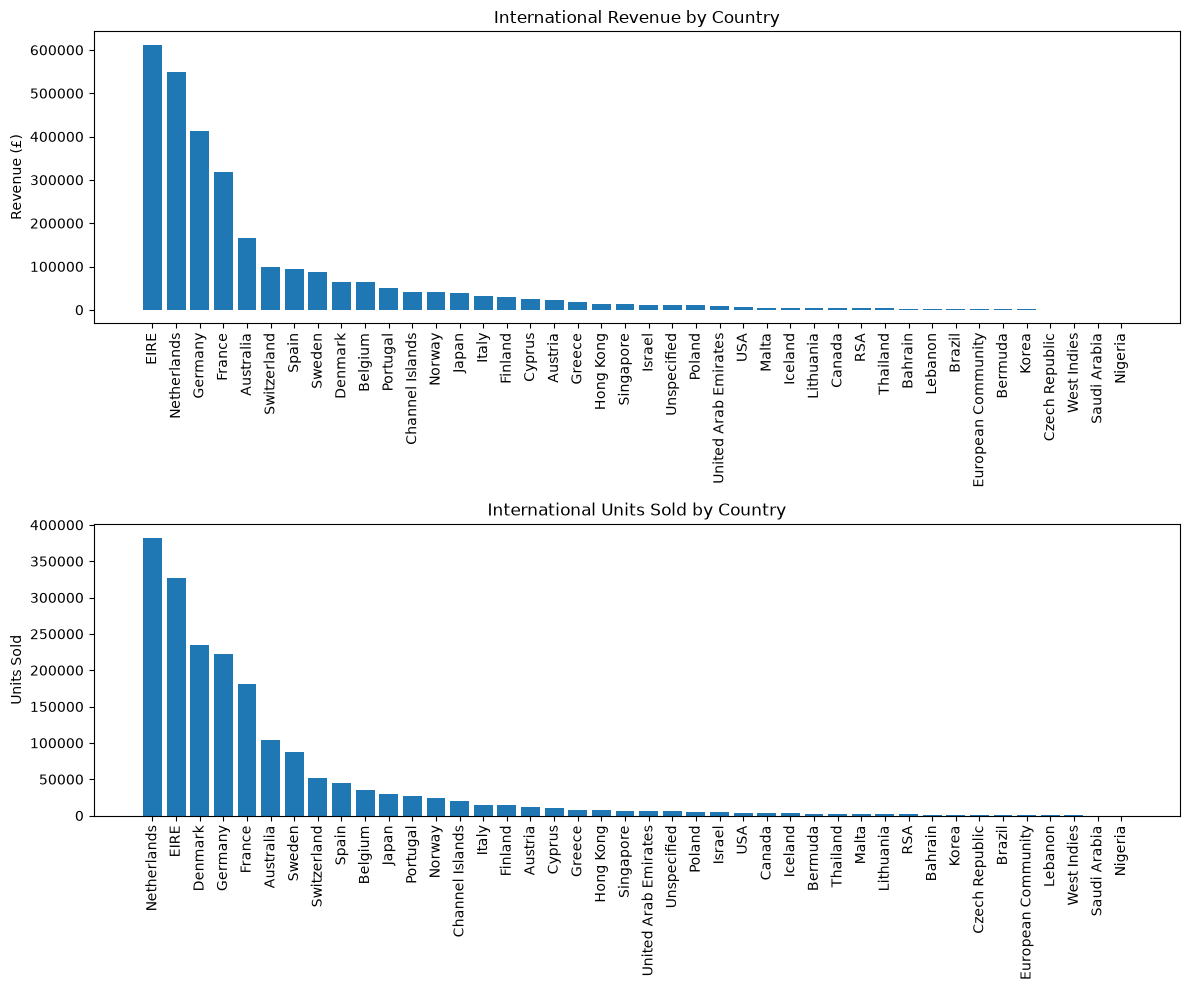

In [50]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Revenue
axes[0].bar(int_rev['Country'], int_rev['Revenue'])
axes[0].set_title('International Revenue by Country')
axes[0].set_ylabel('Revenue (£)')
axes[0].tick_params(axis='x', rotation=90)

# Quantity
axes[1].bar(int_quant['Country'], int_quant['Quantity'])
axes[1].set_title('International Units Sold by Country')
axes[1].set_ylabel('Units Sold')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

- It can be seen that Ireland (EIRE) generates the most amount of revenue, followed by Netherlands, Germany and France.
- Nigeria, Saudi Arabia, West Indies, etc. show very low revenue generation.

In [51]:
uk = df[df['Country'] == 'United Kingdom']

uk_returns = abs(
    uk.loc[uk['is_cancellation'] & (~uk['is_non_product']), 'Revenue'].sum()
)
uk_gross_units_sold = uk.loc[
    (uk['Quantity'] > 0) & (~uk['is_non_product']),
    'Quantity'
].sum()

international = df[df['Country'] != 'United Kingdom']

int_returns = abs(
    international.loc[international['is_cancellation'] & (~international['is_non_product']), 'Revenue'].sum()
)
int_gross_units_sold = international.loc[
    (international['Quantity'] > 0) & (~international['is_non_product']),
    'Quantity'
].sum()

uk_gross_revenue = uk.loc[
    (uk['Revenue'] > 0) & (~uk['is_non_product']),
    'Revenue'
].sum()

int_gross_revenue = international.loc[
    (international['Revenue'] > 0) & (~international['is_non_product']),
    'Revenue'
].sum()

uk_revenue_return_rate = uk_returns / uk_gross_revenue
int_revenue_return_rate = int_returns / int_gross_revenue

print(f"UK Revenue Return Rate: {uk_revenue_return_rate:.4f}")
print(f"International Revenue Return Rate: {int_revenue_return_rate:.4f}")

UK Revenue Return Rate: 0.0376
International Revenue Return Rate: 0.0297


In [52]:
uk_unit_returns = abs(
    uk.loc[uk['is_cancellation'] & (~uk['is_non_product']), 'Quantity'].sum()
)
uk_gross_units_sold = uk.loc[
    (uk['Quantity'] > 0) & (~uk['is_non_product']),
    'Quantity'
].sum()

int_unit_returns = abs(
    international.loc[international['is_cancellation'] & (~international['is_non_product']), 'Quantity'].sum()
)
int_gross_units_sold = international.loc[
    (international['Quantity'] > 0) & (~international['is_non_product']),
    'Quantity'
].sum()

uk_unit_return_rate = uk_unit_returns / uk_gross_units_sold
int_unit_return_rate = int_unit_returns / int_gross_units_sold

print(f"UK Unit Return Rate: {uk_unit_return_rate:.4f}")
print(f"International Unit Return Rate: {int_unit_return_rate:.4f}")

UK Unit Return Rate: 0.0367
International Unit Return Rate: 0.0605


- The UK is the dominant market, generating approximately £16.47M (85%) of total net revenue, while international markets contribute approximately £2.88M (15%).
- Among international markets, EIRE, the Netherlands, Germany and France are the largest contributors to revenue, indicating that international revenue is concentrated among a relatively small number of markets.
- The international market has a slightly lower revenue return rate than the UK, however, the unit return rate is much higher for international markets. 
- These differences suggest that return behaviour may vary by market and could be investigated further if returns become relevant to a specific business question.

In [53]:
country_summary = df.groupby('Country').agg(Revenue=('Revenue','sum'), Customers=('CustomerID','nunique'), Orders=('Invoice','nunique'))
country_summary['RevenuePerCustomer'] = country_summary['Revenue'] / country_summary['Customers']
country_summary.sort_values('RevenuePerCustomer', ascending=False).head(10)

,Revenue,Customers,Orders,RevenuePerCustomer
Country,,,,
Netherlands,548536.36,22,242,24933.470909
Singapore,13158.16,1,8,13158.160000
Australia,166369.42,15,110,11091.294667
EIRE,612351.93,70,733,8747.884714
Denmark,64459.59,12,53,5371.632500
Iceland,4921.53,1,8,4921.530000
Lithuania,4892.68,1,6,4892.680000
Sweden,87793.71,20,124,4389.685500
Switzerland,99403.06,25,123,3976.122400


In [54]:
identified_df = df[~df['is_guest']]

country_summary = identified_df.groupby('Country').agg(
    Revenue=('Revenue','sum'),
    Customers=('CustomerID','nunique'),
    Orders=('Invoice','nunique')
)
country_summary['RevenuePerCustomer'] = country_summary['Revenue'] / country_summary['Customers']
country_summary.sort_values('RevenuePerCustomer', ascending=False).head(10)

,Revenue,Customers,Orders,RevenuePerCustomer
Country,,,,
EIRE,575947.47,3,666,191982.490000
Netherlands,548536.36,22,242,24933.470909
Singapore,13158.16,1,8,13158.160000
Australia,166369.42,15,110,11091.294667
Denmark,64459.59,12,53,5371.632500
Iceland,4921.53,1,8,4921.530000
Lithuania,4892.68,1,6,4892.680000
Sweden,87439.71,19,123,4602.090000
Switzerland,98779.41,22,120,4489.973182


- Ireland: With guests included, EIRE showed 70 "customers" and £8,748 revenue/customer — a broad, moderately valuable market. With guests removed, EIRE drops to just 3 identified customers, but revenue barely moves (£612K → £576K, only ~6% guest-attributed). That means EIRE's real, trackable customer base is 3 accounts averaging ~£192K each — almost certainly wholesale/business buyers, not typical retail shoppers — while the other ~67 "customers" in the guest-inclusive table were just anonymous one-off checkouts inflating the count. The guest-inclusive table made EIRE look like a healthy, broad market; the truth is it's extremely concentrated in a handful of large accounts.
- Netherlands, Australia, Denmark and Japan show identical figures in both tables, meaning they had essentially zero guest-checkout activity. Their per-customer averages (Netherlands £24,933, Australia £11,091) can be trusted as-is — no correction needed, and worth flagging as your most reliable non-UK markets.
- Singapore, Iceland, Lithuania remain single-customer countries either way. Unaffected by the guest filter (no guest orders from these countries), but the original caveat still stands — a "revenue per customer" built from n=1 is an anecdote, not a market signal.

## Orders And Basket Behaviour

In [55]:
# We will only consider actual products that were not cancellations
sales_products = df[
    (~df['is_non_product']) &
    (~df['is_cancellation']) &
    (df['Quantity'] > 0)
]

In [56]:
# Distribution of Items per order
items_per_order = (sales_products.groupby('Invoice')['Quantity'].sum())

print(items_per_order.describe())

count    41296.000000
mean       276.720506
std       1186.416313
min          1.000000
25%         60.000000
50%        143.000000
75%        283.000000
max      87167.000000
Name: Quantity, dtype: float64


In [57]:
print((items_per_order > 1000).sum(), "orders with >1000 items")

1417 orders with >1000 items


In [58]:
# Distribution of Revenue per order
revenue_per_order = (sales_products.groupby('Invoice')['Revenue'].sum())

print(revenue_per_order.describe())

count     41296.000000
mean        475.684367
std        1432.083321
min           0.000000
25%         133.350000
50%         288.525000
75%         469.050000
max      168469.600000
Name: Revenue, dtype: float64


In [59]:
print((revenue_per_order > 1000).sum(), "orders with >1000 revenue")

3410 orders with >1000 revenue


In [60]:
print(sales_products.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10))

CustomerID
18102    580987.04
14646    526751.52
14156    303069.88
14911    272252.79
17450    244784.25
13694    195640.69
17511    172132.87
16446    168472.50
16684    147142.77
12415    144033.37
Name: Revenue, dtype: float64


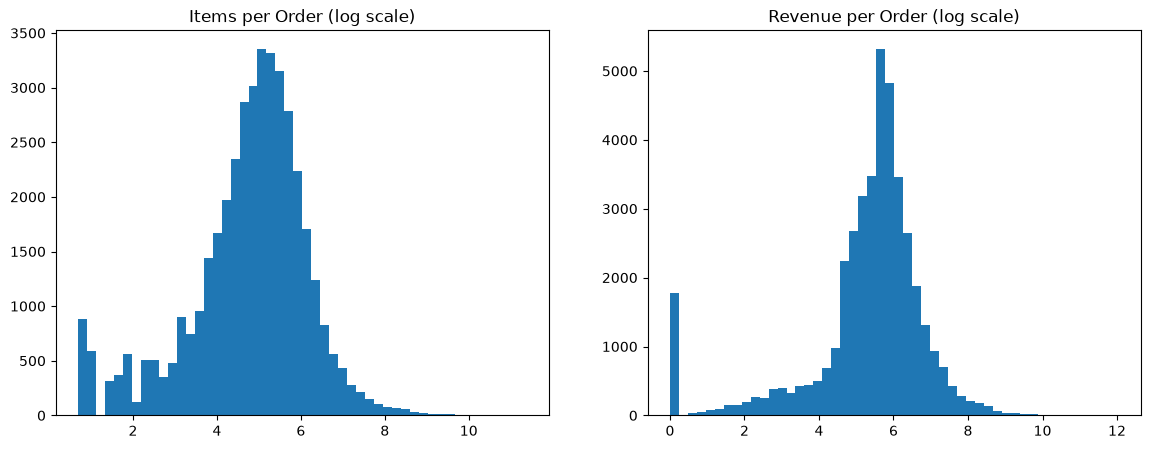

In [61]:
# Visualise the items per order and the revenue per order on a log-scale
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].hist(np.log1p(items_per_order), bins=50); axes[0].set_title('Items per Order (log scale)')
axes[1].hist(np.log1p(revenue_per_order), bins=50); axes[1].set_title('Revenue per Order (log scale)')
plt.show()

Items per order:
- We can see that the minimum number of items is 1 but the maximum is 87K. This shows there are wholesale orders made at once.
- The 75th percentile is at 283 items. This means 75% of the orders have 283 items or less. Only 25% of the orders have items more than 283.
- Also, we can see there are 1417 orders (out of total 41296 as we saw above) that have items more then 1000. These are outliers and should be handled before further analysis.
- The distribution is highly right-skewed, with a small number of exceptionally large orders.
- We can either go for a log-scale or exclude these during segmentation to avoid the clusters being affected by such huge numbers.
- These extreme orders should be assessed carefully before customer-level modelling, as they may represent genuine high-value purchasing behaviour rather than data errors.
  
Revenue per order:  
- This is similar to what we saw above. Order revenue is strongly right-skewed, with a small number of very high-value orders.
- These observations should be considered when constructing customer-level features and clustering models, where extreme values can disproportionately influence the results.

In [62]:
# Distribution of Orders per customer
# Note that we're considering identified customers only
# Guests will have only 1 order per customer as we have used the invoice ID to name the guests
identified_sales = sales_products[~sales_products['is_guest']]

orders_per_customer = (identified_sales.groupby('CustomerID')['Invoice'].nunique())

print(orders_per_customer.describe())

count    5853.000000
mean        6.252691
std        12.750278
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       373.000000
Name: Invoice, dtype: float64


In [63]:
# Again we're only checking the identified customers
one_time_customers = (orders_per_customer == 1).sum()
repeat_customers = (orders_per_customer > 1).sum()

total_identified_customers = len(orders_per_customer)

print(f"One-time customers: {one_time_customers}")
print(f"Repeat customers: {repeat_customers}")

print(
    f"One-time customer share: "
    f"{one_time_customers / total_identified_customers:.2%}"
)

print(
    f"Repeat customer share: "
    f"{repeat_customers / total_identified_customers:.2%}"
)

One-time customers: 1619
Repeat customers: 4234
One-time customer share: 27.66%
Repeat customer share: 72.34%


In [64]:
customer_orders = (identified_sales.groupby('CustomerID')['Invoice'].nunique())

customer_revenue = (identified_sales.groupby('CustomerID')['Revenue'].sum())

customer_summary = pd.DataFrame({
    'Orders': customer_orders,
    'Revenue': customer_revenue
})

customer_summary['CustomerType'] = np.where(
    customer_summary['Orders'] == 1,
    'One-time',
    'Repeat'
)

customer_summary.groupby('CustomerType')['Revenue'].agg(['sum', 'mean'])

,sum,mean
CustomerType,,
One-time,5.560000e+05,343.421848
Repeat,1.651258e+07,3899.995929


- 72.3% of identified customers are repeat buyers, and they generate roughly 11x more average revenue than one-time customers (£3,900 vs. £343 mean).
- Repeat customers generate substantially more revenue per customer than one-time customers, highlighting customer retention as an important area for further analysis.

## Top Products

In [65]:
# Top products by revenue
product_df = df[~df['is_non_product']]
top_product_revenue = product_df.groupby(['StockCode', 'Description'])['Revenue'].sum().reset_index()
print(f"Top 10 products by revenue: ")
top_product_revenue.sort_values('Revenue', ascending=False).head(10)

Top 10 products by revenue: 


,StockCode,Description,Revenue
1646,22423,REGENCY CAKESTAND 3 TIER,314045.02
4314,85123A,WHITE HANGING HEART T-LIGHT HOLDER,248337.61
4286,85099B,JUMBO BAG RED RETROSPOT,178400.52
3158,47566,PARTY BUNTING,147079.73
4004,84879,ASSORTED COLOUR BIRD ORNAMENT,128550.42
1334,22086,PAPER CHAIN KIT 50'S CHRISTMAS,116298.59
3452,79321,CHILLI LIGHTS,79905.13
1441,22197,SMALL POPCORN HOLDER,78903.62
1615,22386,JUMBO BAG PINK POLKADOT,75457.64
3607,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,70969.95


In [66]:
# Top products by Volume
top_products_vol = product_df.groupby(['StockCode', 'Description'])['Quantity'].sum().sort_values(ascending=False).reset_index()
print("Top 10 products by volume: ")
top_products_vol.head(10)

Top 10 products by volume: 


,StockCode,Description,Quantity
0,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,104546
1,85099B,JUMBO BAG RED RETROSPOT,95551
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,94571
3,21212,PACK OF 72 RETROSPOT CAKE CASES,93774
4,22197,SMALL POPCORN HOLDER,88189
5,84879,ASSORTED COLOUR BIRD ORNAMENT,79579
6,17003,BROCADE RING PURSE,69639
7,21977,PACK OF 60 PINK PAISLEY CAKE CASES,55842
8,84991,60 TEATIME FAIRY CAKE CASES,53678
9,15036,ASSORTED COLOURS SILK FAN,43463


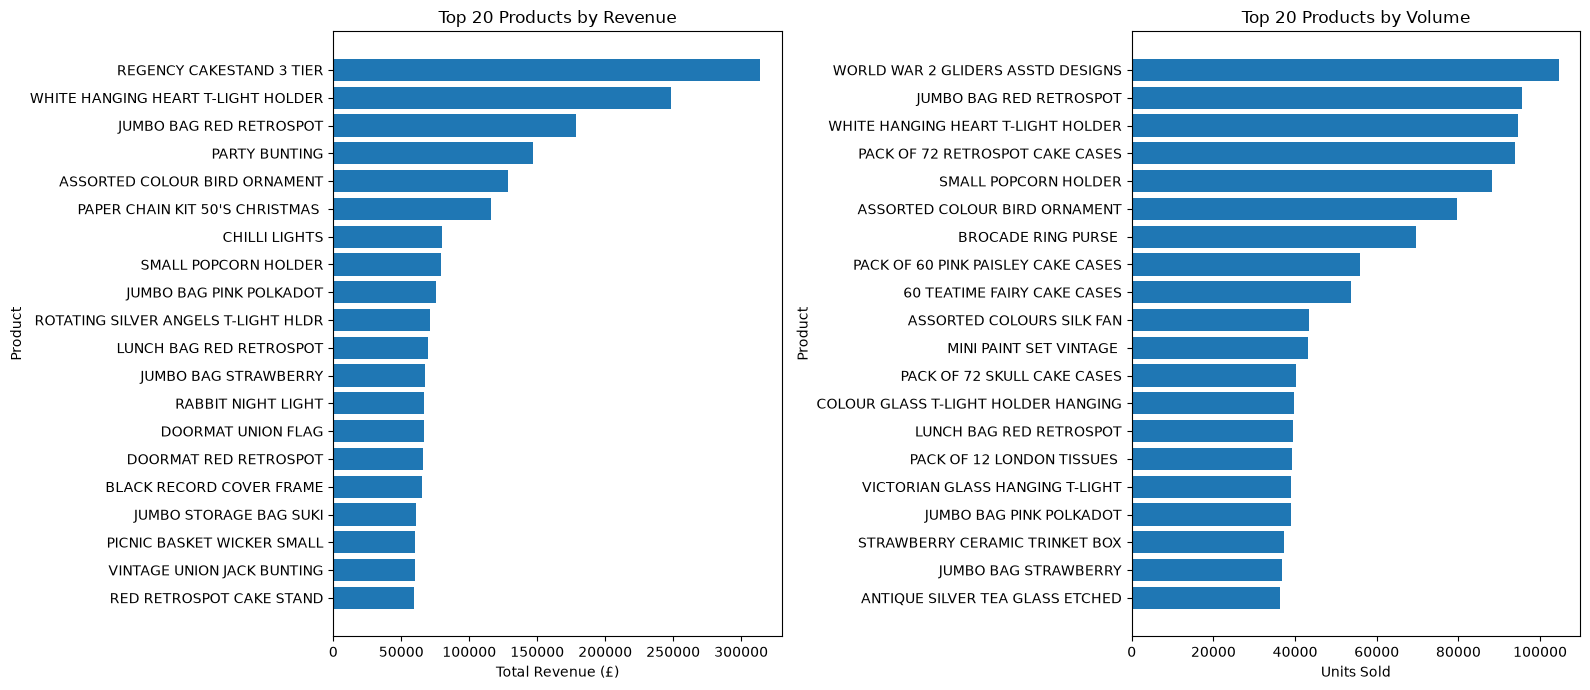

In [67]:
top20_revenue = (
    top_product_revenue
    .sort_values('Revenue', ascending=False)
    .head(20)
    .sort_values('Revenue')
)

top20_volume = (
    top_products_vol
    .sort_values('Quantity', ascending=False)
    .head(20)
    .sort_values('Quantity')
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Revenue
axes[0].barh(
    top20_revenue['Description'],
    top20_revenue['Revenue']
)

axes[0].set_title('Top 20 Products by Revenue')
axes[0].set_xlabel('Total Revenue (£)')
axes[0].set_ylabel('Product')

# Volume
axes[1].barh(
    top20_volume['Description'],
    top20_volume['Quantity']
)

axes[1].set_title('Top 20 Products by Volume')
axes[1].set_xlabel('Units Sold')
axes[1].set_ylabel('Product')

plt.tight_layout()
plt.show()

- Some of the top products sold by volume are also generating the most revenue. Eg. WHITE HANGING HEART T-LIGHT HOLDER, JUMBO BAG RED RETROSPOT.
- It is also worth noting that the most sold product is not in the top 20 for revenue and the most revenue generating product is not in the top sold products.
- A product can sell a huge number of units without generating the most revenue.
- It is worth checking how much revenue the top 10, 20, 50 products are generating.

In [68]:
# Sort products by revenue
product_revenue = (
    top_product_revenue
    .sort_values('Revenue', ascending=False)
    .reset_index(drop=True)
)

# Total revenue across all products
product_total_revenue = product_revenue['Revenue'].sum()

# Calculate cumulative revenue
product_revenue['CumulativeRevenue'] = product_revenue['Revenue'].cumsum()

# Calculate cumulative percentage of total revenue
product_revenue['CumulativeRevenuePct'] = (
    product_revenue['CumulativeRevenue'] / product_total_revenue * 100
)

# Get contribution of top N products
top_n = [10, 20, 50, 100, 1000]

revenue_contribution = []

for n in top_n:
    revenue = product_revenue.head(n)['Revenue'].sum()
    percentage = revenue / product_total_revenue * 100
    
    revenue_contribution.append({
        'Top N Products': n,
        'Revenue %': percentage
    })

revenue_contribution = pd.DataFrame(revenue_contribution)

print(revenue_contribution)

   Top N Products  Revenue %
0              10   7.597178
1              20  10.989411
2              50  19.009420
3             100  28.818260
4            1000  78.945761


In [69]:
product_df['StockCode'].nunique()

4910

- Note that the top 50 products generate around 20% of the revenue.
- Also, there are around 5000 products in total. So let's check how many products generate what percent of the revenue.

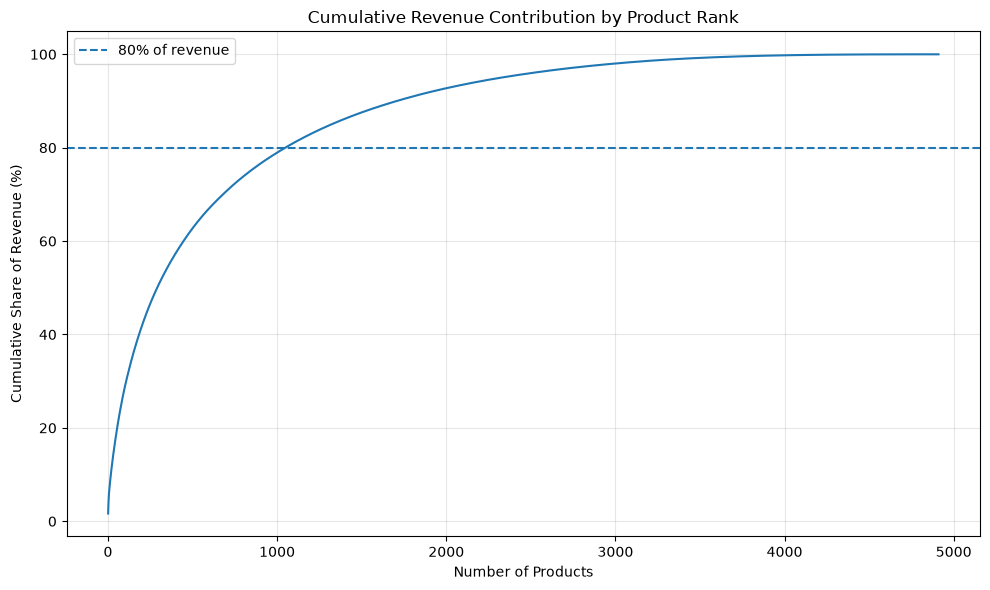

In [70]:
# How many products generate 80% of the revenue?
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(product_revenue) + 1),
    product_revenue['CumulativeRevenuePct']
)

plt.axhline(80, linestyle='--', label='80% of revenue')

plt.xlabel('Number of Products')
plt.ylabel('Cumulative Share of Revenue (%)')
plt.title('Cumulative Revenue Contribution by Product Rank')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

- It can be seen that 80% of the revenue is generated by roughly 20% of the products. This is known as the Pareto Principle.
- This is a moderately concentrated, not extreme, distribution — inventory risk isn't dangerously dependent on a handful of SKUs, but a defined "core" product set exists worth prioritizing for stock and marketing focus.
- We will analyse this further during basket analysis.

## Temporal Analysis

In [71]:
# Datetime columns
df['InvoiceDateTime'] = pd.to_datetime(df['InvoiceDateTime'])
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate']).dt.date
df['InvoiceTime'] = pd.to_datetime(df['InvoiceDateTime']).dt.time  # derive fresh, safer than parsing the string column

# Recreate InvoiceMonth from the now-proper datetime column
df['InvoiceMonth'] = df['InvoiceDateTime'].dt.to_period('M')

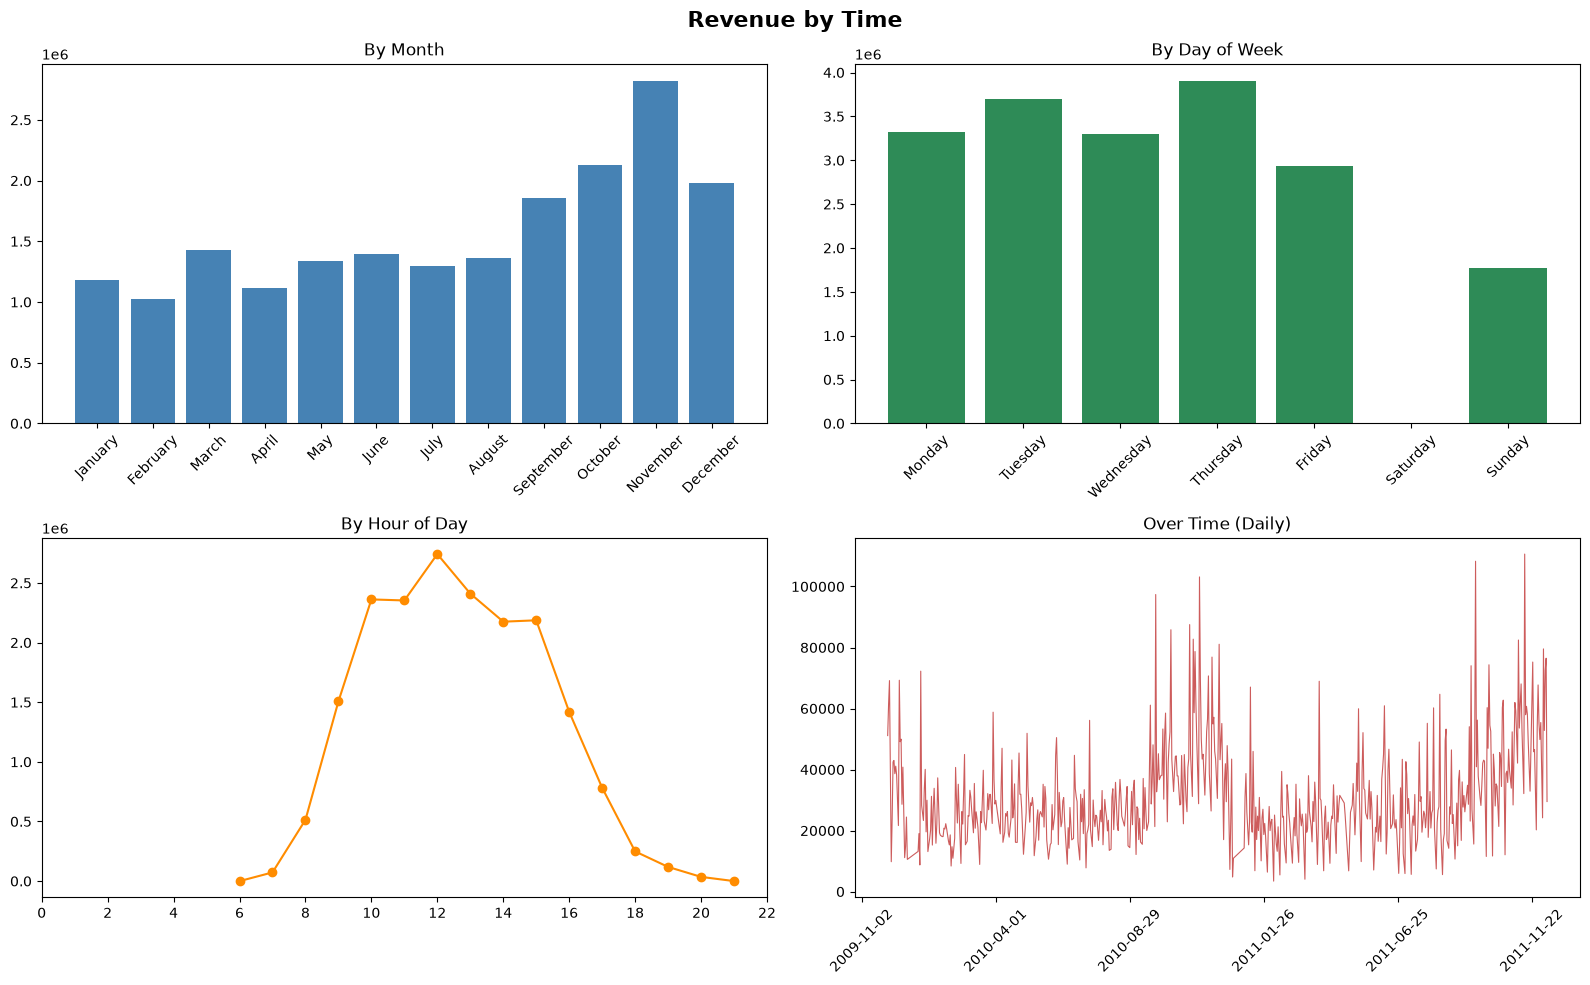

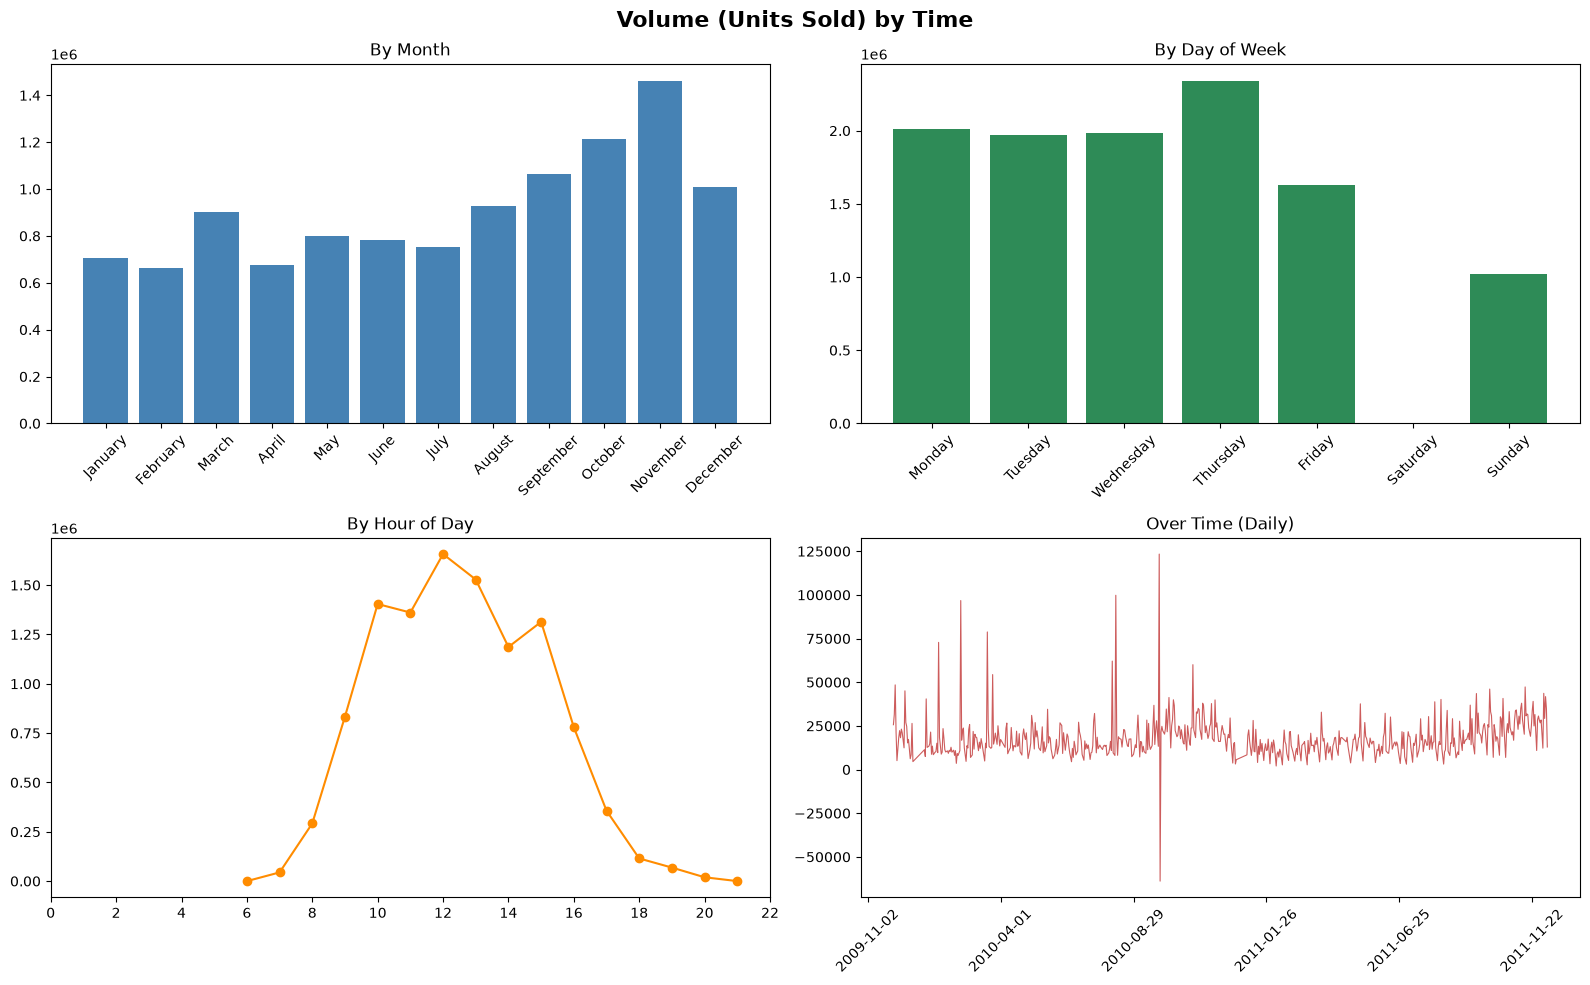

In [72]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Revenue column (net — includes cancellations, so returns correctly reduce revenue)
df['Revenue'] = df['Quantity'] * df['Price']

df['Month'] = df['InvoiceDateTime'].dt.month_name()

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Use a clean, transactional-only view for these charts (drop non-product rows
# like postage/fees so the *shape* of the trend reflects real product activity;
# switch to `df` if you want total revenue including postage/vouchers instead)
plot_df = df[~df.get('is_non_product', False)] if 'is_non_product' in df.columns else df


def plot_time_grid(metric_col, agg_func, title):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # 1. By Month (seasonality across the year, aggregated over both years)
    monthly = plot_df.groupby('Month')[metric_col].agg(agg_func).reindex(month_order)
    axes[0, 0].bar(monthly.index, monthly.values, color='steelblue')
    axes[0, 0].set_title('By Month')
    axes[0, 0].tick_params(axis='x', rotation=45)

    # 2. By Day of Week
    weekly = plot_df.groupby('InvoiceDayOfWeek')[metric_col].agg(agg_func).reindex(day_order)
    axes[0, 1].bar(weekly.index, weekly.values, color='seagreen')
    axes[0, 1].set_title('By Day of Week')
    axes[0, 1].tick_params(axis='x', rotation=45)

    # 3. By Hour of Day
    hourly = plot_df.groupby('InvoiceHour')[metric_col].agg(agg_func)
    axes[1, 0].plot(hourly.index, hourly.values, marker='o', color='darkorange')
    axes[1, 0].set_title('By Hour of Day')
    axes[1, 0].set_xticks(range(0, 24, 2))

    # 4. Full timeline (daily trend across the whole 2-year period)
    daily = plot_df.groupby('InvoiceDate')[metric_col].agg(agg_func)
    axes[1, 1].plot(daily.index, daily.values, color='indianred', linewidth=0.8)
    axes[1, 1].set_title('Over Time (Daily)')
    axes[1, 1].xaxis.set_major_locator(mticker.MaxNLocator(8))
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


# Revenue grid
plot_time_grid('Revenue', 'sum', 'Revenue by Time')

# Volume grid (using Quantity)
plot_time_grid('Quantity', 'sum', 'Volume (Units Sold) by Time')

In [73]:
df['InvoiceDayOfWeek'].value_counts()

InvoiceDayOfWeek
Thursday     195160
Tuesday      190819
Monday       182803
Wednesday    176571
Friday       149197
Sunday       132888
Saturday        400
Name: count, dtype: int64

In [74]:
df[df['InvoiceDayOfWeek'] == 'Saturday']['InvoiceDate'].value_counts()

InvoiceDate
2009-12-05    400
Name: count, dtype: int64

- It can be seen that the highest revenue made and the volume sold was in the month of November, followed by October, September and December.
- This shows a seasonal trend in sales. Sales increase around Christmas.
- Another interesting finding is that most of the transactions are made during the afternoon hours between 10am to 4pm.
- There are virtually no transactions between midnight and 6am. This reflects business-hours ordering pattern.
- It can also be seen that the sales on Saturday are close to 0. There are negligible transactions made on Saturday. This shows that the retailer didn't process orders on Saturdays.
- There is one exception to this - 5th December 2009. The retailer has shipped orders on this particular day in December.

In [75]:
monthly = df[~df['is_non_product']].groupby(df['InvoiceMonth']).agg(
    Revenue=('Revenue','sum'),
    Orders=('Invoice','nunique'),
    Customers=('CustomerID','nunique')
)
# Monthly Average Order Value
monthly['AOV'] = monthly['Revenue'] / monthly['Orders']
monthly['OrdersPerCustomer'] = monthly['Orders'] / monthly['Customers']
print(monthly)

                  Revenue  Orders  Customers         AOV  OrdersPerCustomer
InvoiceMonth                                                               
2009-12        778343.080    2152       1323  361.683587           1.626606
2010-01        604831.792    1377        931  439.238774           1.479055
2010-02        525334.236    1484        981  353.998811           1.512742
2010-03        752102.131    2088       1328  360.202170           1.572289
2010-04        636315.672    1746       1160  364.441966           1.505172
2010-05        606299.140    2012       1327  301.341521           1.516202
2010-06        670209.730    2004       1295  334.435993           1.547490
2010-07        615861.590    1875       1188  328.459515           1.578283
2010-08        661640.120    1724       1178  383.781972           1.463497
2010-09        841556.701    2180       1391  386.035184           1.567218
2010-10       1068984.910    2722       1770  392.720393           1.537853
2010-11     

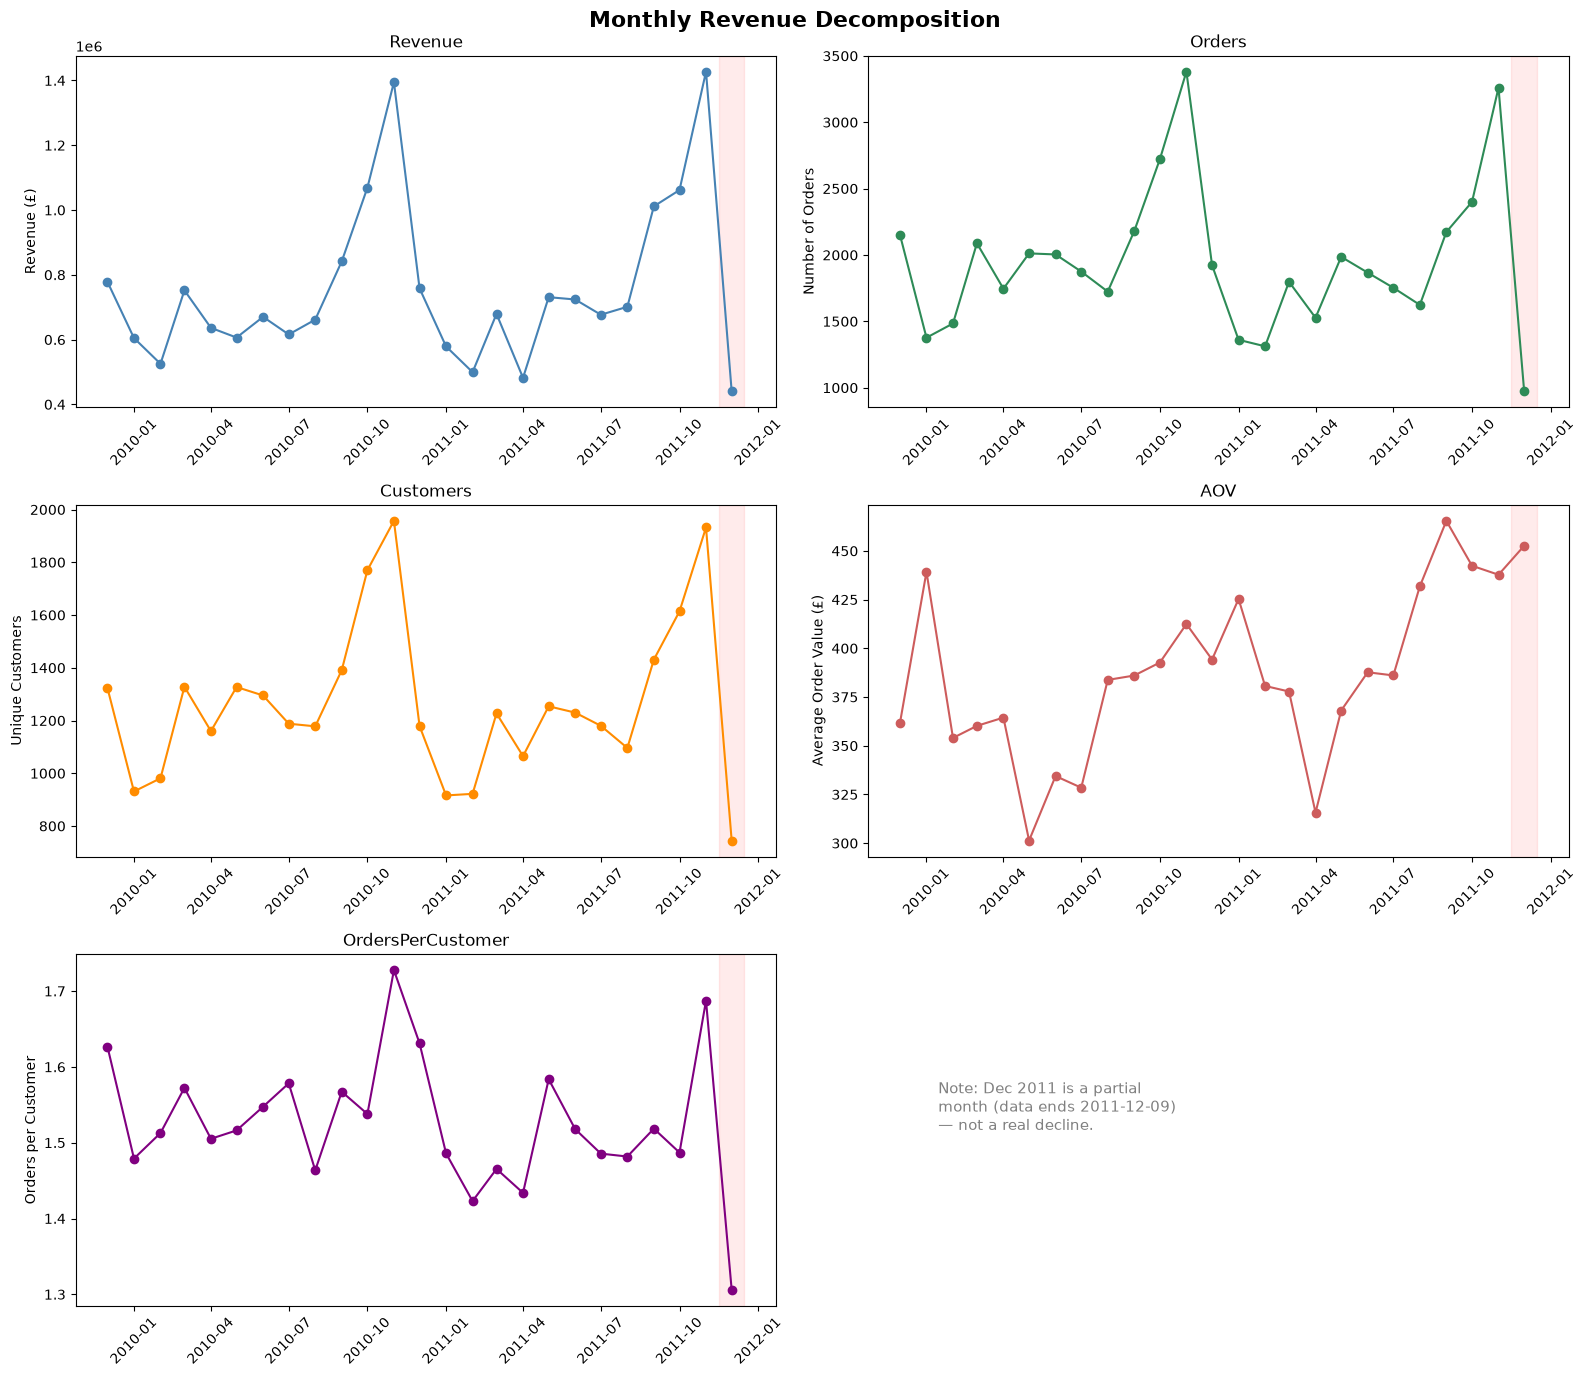

In [76]:
import matplotlib.pyplot as plt

monthly_plot = monthly.copy()
monthly_plot.index = monthly_plot.index.to_timestamp()  # convert Period to Timestamp for plotting

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Monthly Revenue Decomposition', fontsize=16, fontweight='bold')

metrics = [
    ('Revenue', 'Revenue (£)', 'steelblue'),
    ('Orders', 'Number of Orders', 'seagreen'),
    ('Customers', 'Unique Customers', 'darkorange'),
    ('AOV', 'Average Order Value (£)', 'indianred'),
    ('OrdersPerCustomer', 'Orders per Customer', 'purple'),
]

for ax, (col, ylabel, color) in zip(axes.flat, metrics):
    ax.plot(monthly_plot.index, monthly_plot[col], marker='o', color=color)
    ax.set_title(col)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=45)
    # Flag the partial final month
    ax.axvspan(monthly_plot.index[-1] - pd.Timedelta(days=15), monthly_plot.index[-1] + pd.Timedelta(days=15),
               color='red', alpha=0.08)

# Turn off the unused 6th subplot
axes.flat[-1].axis('off')
axes.flat[-1].text(0.1, 0.5, "Note: Dec 2011 is a partial\nmonth (data ends 2011-12-09)\n— not a real decline.",
                    fontsize=11, color='gray')

plt.tight_layout()
plt.show()

- Note that December 2011 is a partial month. The dataset ends on 2011-12-09, hence the values are incomplete.
- Revenue and Customers are mostly increasing together, showing revenue is driven by more people buying, not bigger baskets.
- AOV also increases around November, showing people are buying more, probably gifts due to Christmas season.
- Orders per customer also increases around November, showing the growth is from existing customers buying more during Christmas as well.

## Conclusion

This Global EDA establishes the baseline characteristics of the Online Retail II business ahead of customer- and product-level analysis.

**Scale:** The cleaned dataset covers ~1.03M transaction lines across 49,188 invoices (41,489 non-cancelled orders), generating £19.35M in net revenue across 43 countries and 4,910 products. 5,878 customers can be tracked at an identified, customer level; a further ~4,931 guest checkouts account for 14.8% of revenue but cannot be linked to a persistent identity and are excluded from customer-level analysis (segmentation, CLV).

**Geography:** The UK drives ~85% of net revenue. International markets, led by EIRE, the Netherlands, Germany, and France, contribute the remaining ~15%. International customers return a higher proportion of *units* (6.1% vs. 3.7%) but a lower proportion of *revenue* (3.0% vs. 3.8%) than UK customers — suggesting their returns skew toward lower-value items. Country-level patterns vary sharply once guest checkouts are excluded — EIRE's apparent customer base of 70 collapses to just 3 identified accounts averaging ~£192K each, indicating this market is dominated by a small number of large (likely wholesale) buyers rather than broad retail reach, while Netherlands and Australia show more typical, broadly distributed customer value. International customers also return a higher proportion 
of *units* (6.1% vs. 3.7%) but a lower proportion of *revenue* (3.0% vs. 3.8%) than UK customers, suggesting their returns skew toward lower-value items.

**Customer behaviour:** 72.3% of identified customers are repeat buyers, and they generate roughly 11x more revenue on average than one-time customers (£3,900 vs. £343). This is the strongest single signal in the dataset: revenue is retention-driven, not acquisition-driven, which will directly shape the segmentation and CLV work ahead.

**Order structure:** Order size and value are heavily right-skewed — median order value is £289, but a small number of orders (1,417 with >1,000 items, several customers with >£150K in cumulative revenue) show clear wholesale-scale purchasing patterns rather than typical retail behaviour. These customers will need explicit handling (capping, log-transforming, or separate treatment) before RFM-based clustering, or they risk dominating and distorting segment boundaries.

**Products:** Revenue follows a moderate Pareto pattern — the top \~20% of products (~1,000 of 4,910) generate ~80% of revenue. This is concentrated enough to prioritize a core product set for stock and marketing focus, but not so extreme that the business is fragile to any single product's performance.

**Seasonality & operations:** Revenue and order volume peak sharply in November, driven by a combination of more active customers and moderately larger baskets (AOV also rises) — not purely one factor. The business does not process orders on Saturdays (confirmed structural pattern, not a data quality issue), and the vast majority of transactions occur during UK daytime business hours.